<a href="https://colab.research.google.com/github/Kishoby/Final-Research/blob/Model-Random-Forest/Model_1_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [2]:
path="/content/drive/MyDrive/Research/COMURS/04 09 2025 to 06 08 2025.csv"
df=pd.read_csv(path)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Fiji Islands,Suva,-18.1333,178.4167,Pacific/Fiji,1744189200,2025-04-09 21:00:00,26.1,79.0,Partly cloudy,...,3.330,5.180,1,1,06:14 AM,06:01 PM,03:49 PM,02:53 AM,Waxing Gibbous,82
1,Tuvalu,Funafuti,-8.5167,179.2167,Pacific/Funafuti,1744190100,2025-04-09 21:15:00,29.4,84.9,Overcast,...,2.960,4.995,1,1,06:06 AM,06:03 PM,03:38 PM,03:00 AM,Waxing Gibbous,82
2,Marshall Islands,Majuro,7.1000,171.3833,Pacific/Majuro,1744190100,2025-04-09 21:15:00,28.3,82.9,Overcast,...,11.655,18.500,1,1,06:29 AM,06:43 PM,03:58 PM,03:48 AM,Waxing Gibbous,82
3,New Zealand,Wellington,-41.3000,174.7833,Pacific/Auckland,1744190100,2025-04-09 21:15:00,13.0,55.4,Clear,...,9.250,14.245,1,1,06:45 AM,06:00 PM,04:27 PM,02:36 AM,Waxing Gibbous,82
4,Kiribati,Tarawa,-0.8833,169.5333,Pacific/Tarawa,1744190100,2025-04-09 21:15:00,27.3,81.2,Patchy rain nearby,...,7.955,13.690,1,1,06:41 AM,06:46 PM,04:11 PM,03:48 AM,Waxing Gibbous,82


In [3]:
# Target
target = "air_quality_PM2.5"


features = [
   "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "humidity",
    "cloud",
    "visibility_miles",
    "visibility_km",
    "longitude",
    "gust_kph",        # or gust_mph
    "precip_mm",
    "precip_in",
    "air_quality_Ozone"
]

X = df[features]
y = df[target]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [6]:
y_pred = model.predict(X_test)


In [7]:
# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# R2 Score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


R2 Score: 0.9776309258544337
MSE: 31.711504281118422
RMSE: 5.631296856064189
MAE: 1.9226593041526396
MAPE: 7.429524791272857


#R2 Score: 0.9776309258544337
#MSE: 31.711504281118422
#RMSE: 5.631296856064189
#MAE: 1.9226593041526396
#MAPE: 7.429524791272857

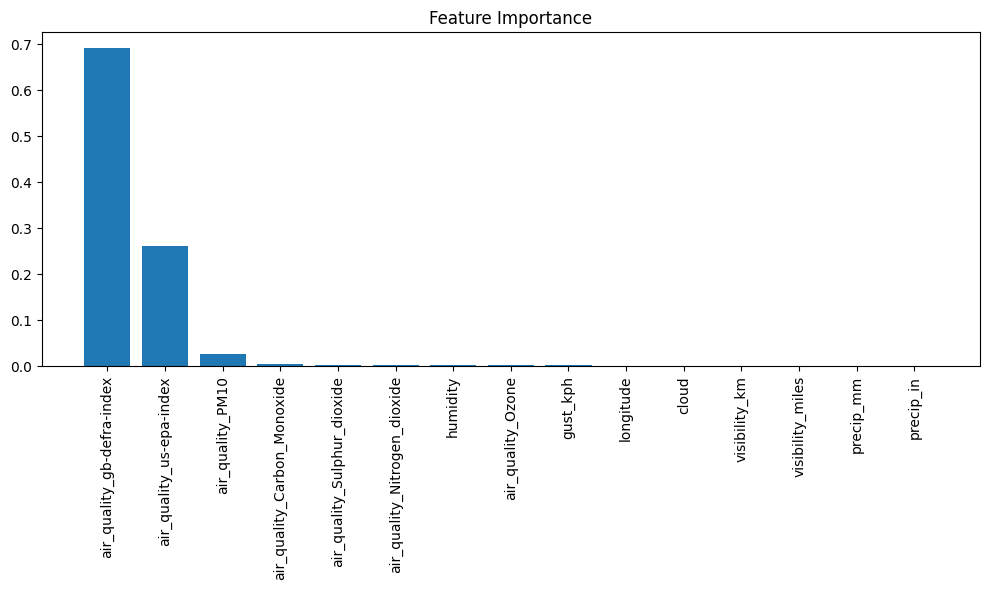

In [8]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), np.array(features)[indices], rotation=90)
plt.tight_layout()
plt.show()


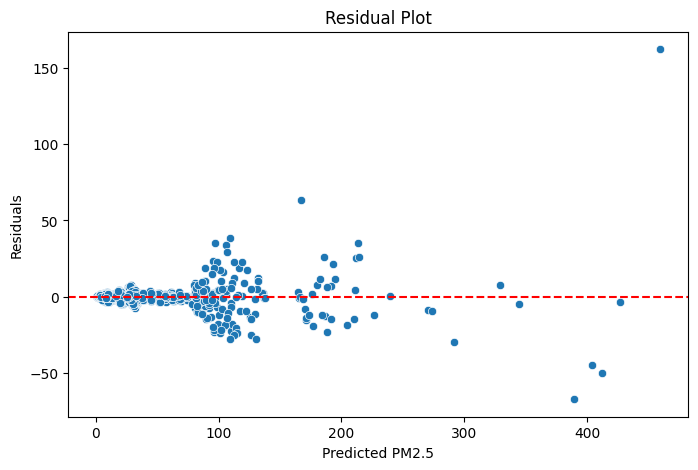

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


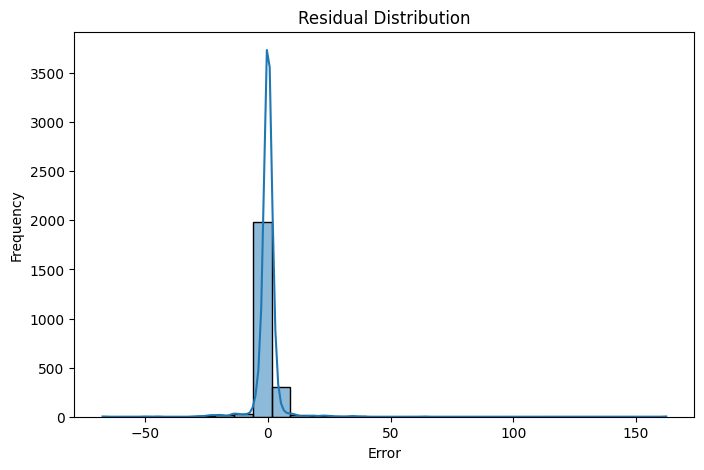

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


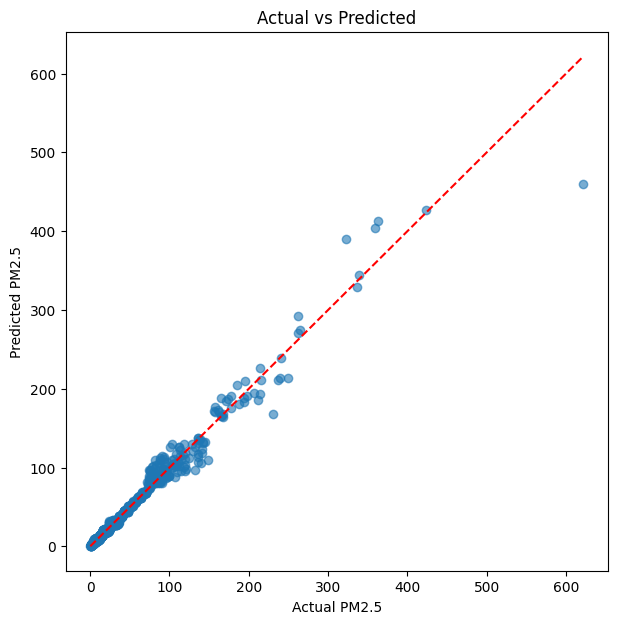

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()
